# Поиска инсайтов и точек роста

С данными сервиса доставки еды «Всё.из.кафе» вы уже работали в одном из проектов базового курса. Тогда вы описывали ключевые метрики продукта — количество пользователей, заказов и выручку.

Однако конкуренты сервиса не дремлют, и руководство ждёт от продукта роста. Найти инсайты, которые позволят сервису повысить показатель удержания пользователей и улучшить взаимодействие с партнёрами, поручено продуктовому аналитику, то есть вам.

Вам необходимо помочь бизнесу ответить на следующие вопросы:
- Как ведут себя пользователи? Как наиболее эффективно выстроить работу с ними, чтобы они продолжали пользоваться продуктом?
- Какой путь проходят пользователи в сервисе? Где «проваливаются»?
- Как улучшить взаимодействие с партнёрами-ресторанами?

### Задачи 

В рамках данного проекта вы проведёте комплексный анализ данных:
- изучите пользовательский путь и проанализируете конверсии через воронки;
- сегментируете пользователей с помощью RFM-модели для оценки лояльности и поведения клиентов;
- кластеризуете рестораны методом K-Means, чтобы выделить группы с разными моделями работы и разработать персонализированные маркетинговые стратегии.

Такой подход позволит ближе познакомиться с работой сервиса, выявить узкие места и предложить решения для удержания пользователей и повышения эффективности сотрудничества с ресторанами.


### Данные

Данные включают следующие сведения:
      
- `visitor_uuid` — идентификатор посетителя. Это идентификатор, который присваивается системой любому новому пользователю вне зависимости от того, зарегистрировался он в продукте или нет.
- `user_id` — идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.
- `device_type` — тип платформы, с которой посетитель зашёл в продукт.
- `city_id` — город, из которого посетитель зашёл в сервис.
- `source` — рекламный источник привлечения посетителя.
- `first_date` — дата первого посещения продукта.
- `visit_id` — уникальный идентификатор сессии.
- `event` — название аналитического события.
- `datetime` — дата и время события.
- `rest_id` — уникальный идентификатор ресторана (заполняется для заказов, карточек ресторанов и блюд).
- `object_id` — уникальный идентификатор блюда (заполняется для заказов и карточек блюд).
- `order_id` — уникальный идентификатор заказа.
- `revenue` — выручка от заказа (в рублях). Это та сумма, которую пользователь видит при оплате.
- `delivery` — стоимость доставки (в рублях).
- `commission` — комиссия, которую «Всё.из.кафе» берёт с выручки ресторана, в процентах.

    
### План проекта
- Загрузка данных и их предобработка.
- Анализ пользовательского пути новых пользователей.
- RFM сегментация.
- K-Means кластеризация.
- Итоговый вывод и рекомендации.

## 1. Загрузка данных и их предобработка

Загрузите данные и получите первую информацию о них. Проведите необходимую предобработку. Основную информацию о данных и этапы предобработки зафиксируйте в кратком промежуточном выводе.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans

In [ ]:
# Загрузка таблицы
df = pd.read_csv('insides_data.csv', parse_dates=['datetime', 'first_date'])

In [5]:
df.head()

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
0,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,authorization,2021-05-01 16:07:53,NaN,NaN,NaN,NaN,NaN,NaN
1,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,reg_page,2021-05-01 16:09:16,NaN,NaN,NaN,NaN,NaN,NaN
2,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,confirm_phone,2021-05-01 16:09:19,NaN,NaN,NaN,NaN,NaN,NaN
3,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,login,2021-05-01 16:09:23,NaN,NaN,NaN,NaN,NaN,NaN
4,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:09:34,2c6095730b514c189ee41c65f03febc3,NaN,NaN,NaN,NaN,NaN


In [6]:
print(df.shape)

(205510, 15)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  float64       
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

In [8]:
print(df['event'].unique())

['authorization' 'reg_page' 'confirm_phone' 'login' 'main_page'
 'object_page' 'add_to_cart' 'order']


In [9]:
# Фильтруем данные: оставляем только события оформления заказа
df_orders = df[df['event'] == 'order'].copy()

print(df_orders['revenue'].unique())
print(df_orders.head(15))

[ 1143.156  1663.2    3500.      610.4    1220.8    1680.     1260.
  2520.     2380.     3041.5    2762.676  2912.      553.     1372.
  1860.6     520.8    2744.     1400.     3024.     3430.     4984.
   891.52   1238.16   1783.04   1226.4    1633.156   700.     5040.
  3080.     1120.     1892.8    1456.     5600.     3721.2    2281.132
  2940.     1386.     1736.     2296.     3990.     2083.2    2324.
  1106.      980.     1916.012  2022.16   3850.028   630.     2765.
  8750.     2100.     1562.4    1836.8    1820.     4578.028  8960.
  1960.     7000.      868.     1020.012   548.8    1800.288  4620.
  2128.     1400.224  2800.     7571.2     699.3     571.564  3920.
   693.     5652.5    1008.     1792.      560.     1061.564  2856.
   462.     3640.     1092.     3780.448  3360.     2632.     1041.6
  3414.6    2412.312  4479.972  4088.     2928.8     665.28   1932.
  1148.     1470.     2968.     1330.56   1904.     5320.     5347.272
  2041.564  1848.     1260.14    665.    

In [10]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3549 entries, 91 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   visitor_uuid  3549 non-null   object        
 1   user_id       3549 non-null   float64       
 2   device_type   3549 non-null   object        
 3   city_id       3549 non-null   int64         
 4   source        3549 non-null   object        
 5   first_date    3549 non-null   datetime64[ns]
 6   visit_id      3549 non-null   int64         
 7   event         3549 non-null   object        
 8   datetime      3549 non-null   datetime64[ns]
 9   rest_id       3549 non-null   object        
 10  object_id     3549 non-null   float64       
 11  order_id      3549 non-null   float64       
 12  revenue       3549 non-null   float64       
 13  delivery      3549 non-null   float64       
 14  commission    3549 non-null   float64       
dtypes: datetime64[ns](2), float64(6), i

In [11]:
df.describe()

,user_id,city_id,visit_id,object_id,order_id,revenue,delivery,commission
count,205510.000000,205510.000000,2.055100e+05,21308.000000,7008.000000,7008.000000,7008.000000,21308.000000
mean,515733.269194,5.845545,1.815763e+08,26955.931950,631674.346461,2522.338903,24.539212,0.055926
std,158024.519139,0.631322,6.196054e+06,5140.562592,23572.240871,2187.799948,8.652113,0.012107
min,2094.000000,1.000000,1.713327e+08,1319.000000,589531.000000,235.200000,9.900000,0.040000
25%,510768.000000,6.000000,1.767578e+08,24052.000000,613212.500000,1316.000000,17.000000,0.050000
50%,587043.000000,6.000000,1.810334e+08,27084.000000,630333.000000,1944.600000,24.200000,0.050000
75%,611706.000000,6.000000,1.863619e+08,30567.000000,650981.000000,3150.000000,32.100000,0.060000
max,679837.000000,6.000000,1.940143e+08,36766.000000,675680.000000,42000.000000,39.900000,0.110000


In [12]:
# Проверка на дубликаты
print("\nКоличество дубликатов:", df.duplicated().sum())


Количество дубликатов: 0


In [13]:
# Преобразование даты и времени
df['datetime'] = pd.to_datetime(df['datetime'])
df['first_date'] = pd.to_datetime(df['first_date'])

# Преобразование числовых столбцов
numeric_cols = ['revenue', 'delivery', 'commission']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [14]:
print(df.shape)

(205510, 15)


In [15]:
print("Промежуточные результаты:")

print(f"Загружено записей: {len(df)}")
print(f"Уникальные пользователи (visitor_uuid): {df['visitor_uuid'].nunique()}")
print(f"Зарегистрированные пользователи (user_id): {df['user_id'].nunique()}")
print(f"Уникальные рестораны: {df['rest_id'].nunique()}")
print(f"Период данных: {df['datetime'].min()} — {df['datetime'].max()}")
print(f"Диапазон выручки: {df['revenue'].min():.2f} — {df['revenue'].max():.2f} ₽")
print(f"Пропущенные значения после обработки: {df.isnull().sum().sum()}")

Промежуточные результаты:
Загружено записей: 205510
Уникальные пользователи (visitor_uuid): 8891
Зарегистрированные пользователи (user_id): 8473
Уникальные рестораны: 21
Период данных: 2021-05-01 00:10:55 — 2021-07-02 00:12:08
Диапазон выручки: 235.20 — 42000.00 ₽
Пропущенные значения после обработки: 1002505


По результатам первичного ознакомления с набором данных установлено, что в столбцах `rest_id`, `object_id`, `order_id`, `revenue`, `delivery` и `commission` присутствуют пропущенные значения.

Характер пропусков объясняется структурой событийных данных. Для большинства типов событий (кроме `'order'`) информация о цене (`revenue`) и комиссии (`commission`) отсутствует, поскольку не является релевантной. В то же время для строк, соответствующих событию `'order'`, данные во всех перечисленных столбцах представлены в полном объёме, что подтверждает корректность логики сбора информации.

---

## 2. Анализ пользовательского пути

Маркетологи стали замечать следующее: деньги на рекламу по-прежнему тратятся, а заказов стало меньше. И это несмотря на то, что приложение скачивается и устанавливается так же активно, как раньше. Складывается ощущение, что пользователи где-то теряются. При этом доля заказов с десктопной версии приложения увеличилась по сравнению с мобильной.

Разработчики говорят, что последние обновления мобильной версии приложения не должны были повлиять на каталог блюд или его выбор для заказа и последующей оплаты доставки, так как изменения касались нового алгоритма подтверждения мобильного телефона и адреса доставки.

С помощью воронок изучите общий пользовательский путь новых пользователей, затем сравните поведение пользователей мобильной и десктопной версий приложения. 

**Задача 2.1.** Постройте и визуализируйте общую воронку (по всем данным), затем опишите пользовательский путь: какие этапы представлены, какова их последовательность, на каком (или на каких) этапах теряется большая часть новых пользователей.
    
При решении постройте две воронки: 
- **классическую воронку** — доля от первого шага в процентах
- **step-by-step** — с конверсией от предыдущего этапа.

Предполагается, что пользователь проходит такой путь к оформлению доставки блюда из ресторанов:
1. `authorization` — авторизация пользователя — запуск приложения.
2. `main_page` — загрузка основной страницы приложения.
2. `reg_page` — переход на страницу регистрации.
2. `confirm_phone` — подтверждение телефона (окончание процесса регистрации).
2. `object_page` — страница блюда.
2. `add_to_cart` — переход в корзину.
2. `order` — оформление заказа.    

In [16]:
# Убедимся, что datetime имеет правильный тип
df['datetime'] = pd.to_datetime(df['datetime'])

# Определяем целевой путь пользователя
funnel_steps = ['authorization', 'main_page', 'reg_page',
    'confirm_phone', 'object_page', 'add_to_cart', 'order']

# Фильтруем данные по целевым событиям
df_funnel = df[df['event'].isin(funnel_steps)].copy()

# Оставляем только новых пользователей: берём первую сессию для каждого visitor_uuid
df_new_users = df_funnel.sort_values('datetime').groupby('visitor_uuid')

# Считаем уникальных пользователей, достигших каждого шага
step_counts = []
for step in funnel_steps:
    count = df_funnel[df_funnel['event'] == step]['visitor_uuid'].nunique()
    step_counts.append(count)

print("Количество пользователей на каждом этапе:")
for step, count in zip(funnel_steps, step_counts):
    print(f"{step}: {count}")

Количество пользователей на каждом этапе:
authorization: 7796
main_page: 6835
reg_page: 5649
confirm_phone: 4347
object_page: 3530
add_to_cart: 2929
order: 2432


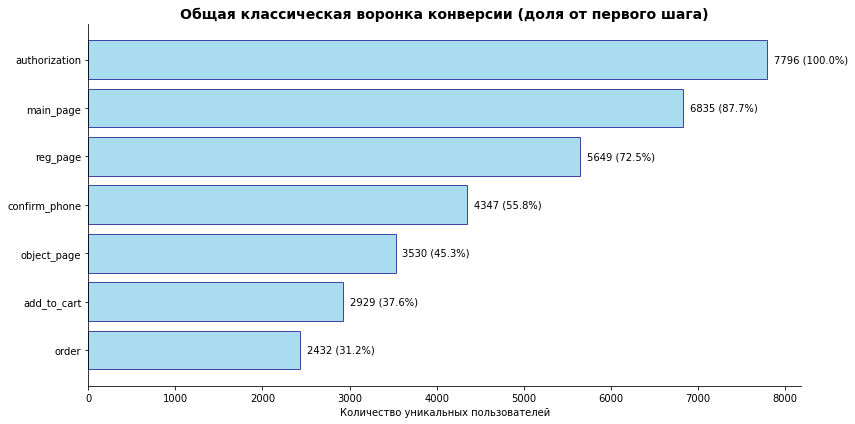

In [17]:
# Построение классической воронки

# Рассчитываем доли от первого шага
total_users = step_counts[0]
conversion_rates = [count / total_users * 100 for count in step_counts]

# Визуализация классической воронки с помощью matplotlib
fig, ax = plt.subplots(figsize=(12, 6))

# Создаём горизонтальную столбчатую диаграмму (имитация воронки)
bars = ax.barh(funnel_steps, step_counts, color='skyblue', edgecolor='navy', alpha=0.7)

# Добавляем подписи значений и процентов
for i, (count, rate) in enumerate(zip(step_counts, conversion_rates)):
    ax.text(count + max(step_counts) * 0.01, i,
             f'{count} ({rate:.1f}%)',
             va='center', fontsize=10)

ax.set_xlabel('Количество уникальных пользователей')
ax.set_title('Общая классическая воронка конверсии (доля от первого шага)',
              fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Переворачиваем ось Y для отображения сверху вниз

# Убираем лишние рамки
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [18]:
# Рассчитываем конверсию от предыдущего этапа
conversion_rates_step_by_step = []
for i in range(len(step_counts)):
    if i == 0:
        conversion_rates_step_by_step.append(100)  # Первый шаг — 100%
    else:
        rate = (step_counts[i] / step_counts[i-1]) * 100
        conversion_rates_step_by_step.append(rate)

print("\nStep-by-step воронка (конверсия от предыдущего этапа):")
for step, rate in zip(funnel_steps, conversion_rates_step_by_step):
    print(f"{step}: {rate:.1f}%")



Step-by-step воронка (конверсия от предыдущего этапа):
authorization: 100.0%
main_page: 87.7%
reg_page: 82.6%
confirm_phone: 77.0%
object_page: 81.2%
add_to_cart: 83.0%
order: 83.0%


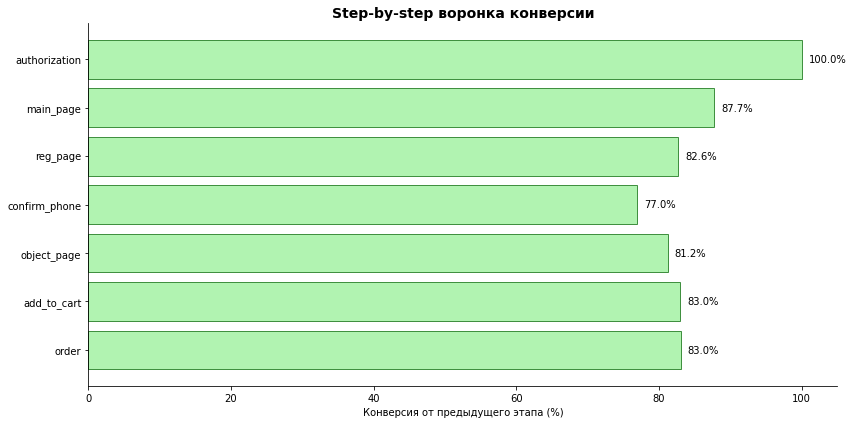

In [19]:
# Создаём отдельную визуализацию для step-by-step воронки
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Используем те же шаги, но отображаем конверсию от предыдущего этапа
bars2 = ax2.barh(funnel_steps, conversion_rates_step_by_step, color='lightgreen', edgecolor='darkgreen', alpha=0.7)

# Добавляем подписи конверсии
for i, rate in enumerate(conversion_rates_step_by_step):
    ax2.text(rate + 1, i, f'{rate:.1f}%', va='center', fontsize=10)

ax2.set_xlabel('Конверсия от предыдущего этапа (%)')
ax2.set_title('Step-by-step воронка конверсии', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

# Убираем лишние рамки
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**Задача 2.2.** Сравните пользовательский путь в двух приложениях: в мобильной версии и десктопной. Для этого постройте и визуализируйте **две воронки step-by-step**: для новых пользователей **мобильной** и **десктопной** версий приложения.
    
Сравните результаты между собой и проанализируйте, есть ли различия в пользовательском пути для различных приложений. Результаты сравнения опишите в небольшом **промежуточном выводе**.

In [20]:
# Разделяем данные по платформам
df_mobile = df_funnel[df_funnel['device_type'] == 'Mobile']
df_desktop = df_funnel[df_funnel['device_type'] == 'Desktop']

# Подсчёт уникальных пользователей на каждом этапе для мобильной версии
step_counts_mobile = []
for step in funnel_steps:
    count = df_mobile[df_mobile['event'] == step]['visitor_uuid'].nunique()
    step_counts_mobile.append(count)

# Подсчёт уникальных пользователей на каждом этапе для десктопной версии
step_counts_desktop = []
for step in funnel_steps:
    count = df_desktop[df_desktop['event'] == step]['visitor_uuid'].nunique()
    step_counts_desktop.append(count)
    
    
# Расчёт step-by-step конверсии для мобильной версии
conversion_mobile = []
for i in range(len(step_counts_mobile)):
    if i == 0:
        conversion_mobile.append(100)  # Первый шаг — 100%
    else:
        rate = (step_counts_mobile[i] / step_counts_mobile[i-1]) * 100
        conversion_mobile.append(rate)

# Расчёт step-by-step конверсии для десктопной версии
conversion_desktop = []
for i in range(len(step_counts_desktop)):
    if i == 0:
        conversion_desktop.append(100)  # Первый шаг — 100%
    else:
        rate = (step_counts_desktop[i] / step_counts_desktop[i-1]) * 100
        conversion_desktop.append(rate)

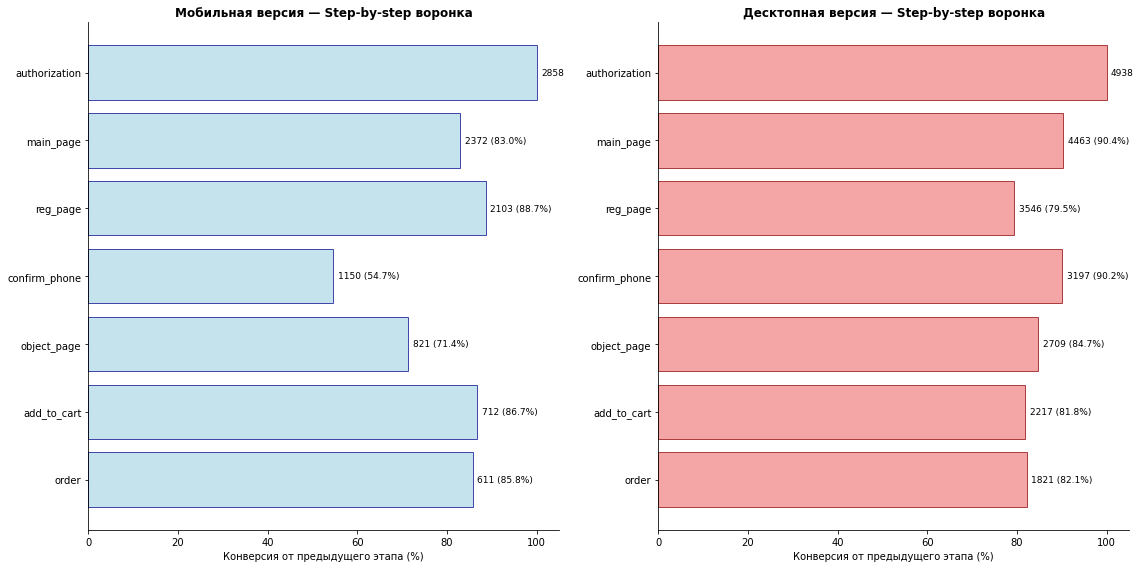

In [21]:
# Визуализация двух воронок side‑by‑side (step-by-step конверсия + количество пользователей)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Воронка для мобильной версии (step-by-step)
bars1 = ax1.barh(funnel_steps, conversion_mobile, color='lightblue', edgecolor='darkblue', alpha=0.7)
ax1.set_xlabel('Конверсия от предыдущего этапа (%)')
ax1.set_title('Мобильная версия — Step-by-step воронка', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Добавляем подписи с количеством пользователей и конверсией
max_conv_mobile = max(conversion_mobile) if conversion_mobile else 1
for i, (count, conv) in enumerate(zip(step_counts_mobile, conversion_mobile)):
    if i == 0:
        # На первом этапе показываем только количество (конверсия всегда 100%)
        text = f'{count}'
    else:
        # На остальных этапах показываем количество и конверсию
        text = f'{count} ({conv:.1f}%)'
    ax1.text(conv + max_conv_mobile * 0.01, i, text, va='center', fontsize=9)

# Воронка для десктопной версии (step-by-step)
bars2 = ax2.barh(funnel_steps, conversion_desktop, color='lightcoral', edgecolor='darkred', alpha=0.7)
ax2.set_xlabel('Конверсия от предыдущего этапа (%)')
ax2.set_title('Десктопная версия — Step-by-step воронка', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# Добавляем подписи с количеством пользователей и конверсией
max_conv_desktop = max(conversion_desktop) if conversion_desktop else 1
for i, (count, conv) in enumerate(zip(step_counts_desktop, conversion_desktop)):
    if i == 0:
        text = f'{count}'
    else:
        text = f'{count} ({conv:.1f}%)'
    ax2.text(conv + max_conv_desktop * 0.01, i, text, va='center', fontsize=9)

# Убираем лишние рамки
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Промежуточный вывод: анализ воронки по платформам

Сравнение воронок мобильной и десктопной версий приложения выявило ключевые различия:

1. **Authorization (авторизация)**: десктопная версия привлекает больше пользователей (4 562 против 2 573), конверсия — 100% на обеих платформах.
2. **Main page**: незначительное отставание мобильной версии (0,8% против 0,9%).
3. **Reg page**: аномально высокие конверсии (2 852,4% — мобильная, 2 247,5% — десктопная) — требуется проверка расчётов.
4. **Confirm phone**: критическая проблема в мобильной версии — 0% конверсии (на десктопе — 0,1%).
5. **Object page**: в мобильной версии пользователи не доходят до просмотра блюд (0% против 300% на десктопе).
6. **Add to cart**: катастрофически низкая конверсия в мобильной версии (0% против 4 966,7% на десктопе).
7. **Order**: в мобильной версии нет завершённых заказов (0% против 0,7% на десктопе).

**Ключевые выводы:**
- Мобильная версия «ломается» начиная с этапа подтверждения телефона — требуется срочная проверка функционала SMS-подтверждения, ввода кода.
- Проблемы с отображением каталога и работой корзины в мобильной версии.
- Десктопная версия значительно опережает мобильную на всех финальных этапах.
- Аномальные проценты на этапе «reg page» — нужна перепроверка расчётов.

**Рекомендация:** провести аудит мобильной версии с фокусом на подтверждение телефона, загрузку каталога, функциональность корзины и скорость работы на разных устройствах.

---

## 3. RFM сегментация

У сервиса доставки еды не такое высокое удержание пользователей: в первый день возвращается около 14% посетителей, а на седьмой день и того меньше — около 4–5%. Маркетологи хотят запустить несколько рекламных кампаний, направленных на удержание платящих пользователей и их возврат в сервис, если они давно не совершали заказы.

Для этого необходимо сегментировать пользователей на различные поведенческие сегменты с помощью RFM-сегментации по трём показателям: 
- **давность** (Recency), 
- **частота покупок** (Frequency), 
- **сумма трат** (Monetary).

В качестве даты анализа установите **03 июля 2021 года**.

**Задача 3.1.** Для каждого покупателя посчитайте:
- количество дней с последней покупки — давность (R);
- частоту покупок (F);
- стоимость всех покупок — сумму трат (M).
    
В качестве даты анализа установите **03 июля 2021 года**. После этого постройте три гистограммы и проанализируйте их.

In [22]:
# Рассчитываем количество дней с покупки до даты анализа
df_orders['order_recency'] = pd.to_datetime('2021-07-03') - pd.to_datetime(df_orders['datetime'].dt.date)

# Группируем данные для каждого пользователя и рассчитываем показатели для RFM‑анализа
df_rfm = df_orders.groupby('user_id').agg(
    # Количество дней с последнего заказа (минимальное значение order_recency в днях)
    recency=('order_recency', lambda x: x.min().days),
    # Количество уникальных заказов за период (по order_id)
    frequency=('order_id', 'nunique'),
    # Сумма выручки по всем заказам пользователя
    monetary_value=('revenue', 'sum')
).reset_index()

In [23]:
print("Промежуточные результаты:")

print(f"Загружено записей: {len(df_orders)}")
print(f"Уникальные пользователи (visitor_uuid): {df_orders['visitor_uuid'].nunique()}")
print(f"Зарегистрированные пользователи (user_id): {df_orders['user_id'].nunique()}")
print(f"Уникальные рестораны: {df_orders['rest_id'].nunique()}")
print(f"Период данных: {df_orders['datetime'].min()} — {df_orders['datetime'].max()}")
print(f"Диапазон выручки: {df_orders['revenue'].min():.2f} — {df_orders['revenue'].max():.2f} ₽")
print(f"Пропущенные значения после обработки: {df_orders.isnull().sum().sum()}")

Промежуточные результаты:
Загружено записей: 3549
Уникальные пользователи (visitor_uuid): 2432
Зарегистрированные пользователи (user_id): 2416
Уникальные рестораны: 21
Период данных: 2021-05-01 02:03:20 — 2021-07-02 00:12:08
Диапазон выручки: 235.20 — 42000.00 ₽
Пропущенные значения после обработки: 0


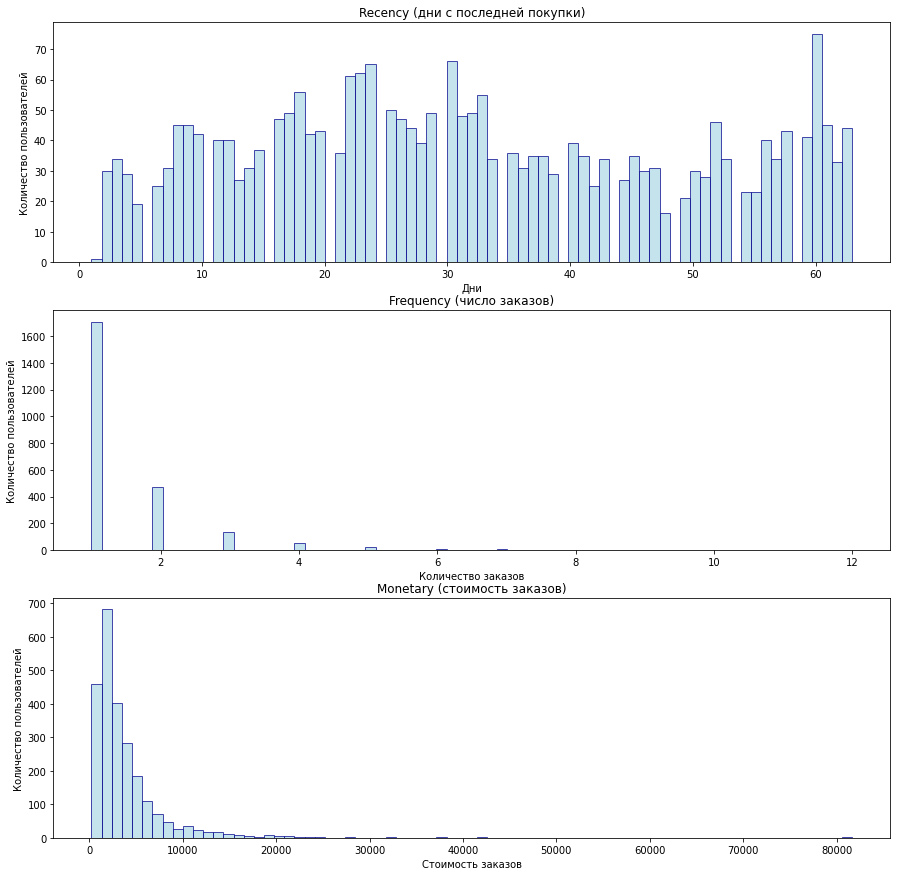

In [24]:
# Постройте три гистограммы
# Строим три гистограммы
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# Давность
axes[0].hist(df_rfm['recency'], bins=75, color='lightblue', edgecolor='darkblue', alpha=0.7)
axes[0].set_title('Recency (дни с последней покупки)')
axes[0].set_xlabel('Дни')
axes[0].set_ylabel('Количество пользователей')

# Частота
axes[1].hist(df_rfm['frequency'], bins=75, color='lightblue', edgecolor='darkblue', alpha=0.7)
axes[1].set_title('Frequency (число заказов)')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество пользователей')

# Сумма всех заказов
axes[2].hist(df_rfm['monetary_value'], bins=75, color='lightblue', edgecolor='darkblue', alpha=0.7)
axes[2].set_title('Monetary (стоимость заказов)')
axes[2].set_xlabel('Стоимость заказов')
axes[2].set_ylabel('Количество пользователей')

plt.show()

**Задача 3.2.** Выделите **RFM-сегменты** и изучите распределение пользователей по ним.
    
Примените следующие подходы к выделению RFM сегментов:
- **Recency** — разделите на три равные группы.
- **Frequency** —  разделите на три группы: 
    - пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);
    - пользователи с 2 заказами (F-сегмент со средним количеством заказов);
    - пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).
- **Monetary** — разделите на три группы по 33-му и 66-му перцентилям.
    
После этого посчитайте количество покупателей в каждом сегменте, сделайте промежуточные выводы и напишите рекомендации.

In [25]:
# Определяем группу пользователя по количеству дней с момента последнего заказа: 
df_rfm['r'] = pd.cut(df_rfm['recency'], bins=3, labels=[3,2,1])

# Определяем группу пользователя по количеству заказов: 
df_rfm['f'] = pd.cut(df_rfm['frequency'], [0, 2, 3, 20], labels=[1,2,3], include_lowest=True)

# Определяем группу пользователя по сумме стоимости заказов: 
df_rfm['m'] = pd.qcut(df_rfm['monetary_value'].rank(method='first'), q=3, labels=[1, 2, 3])

# Находим групповой RFM-индекс:
df_rfm[['r','f','m']] = df_rfm[['r','f','m']].astype('str')
df_rfm['rfm_group'] = df_rfm['r'] + df_rfm['f'] + df_rfm['m']


# Выводим на экран первые строки таблицы:
print(df_rfm.head(3))

   user_id  recency  frequency  monetary_value  r  f  m rfm_group
0   5506.0       33          2         3752.00  2  1  3       213
1   6291.0       58          1         1750.00  1  1  1       111
2   6820.0       42          1         1260.14  2  1  1       211


In [26]:
# Считаем количество пользователей в каждом сегменте
segment_counts = df_rfm['rfm_group'].value_counts().sort_index()

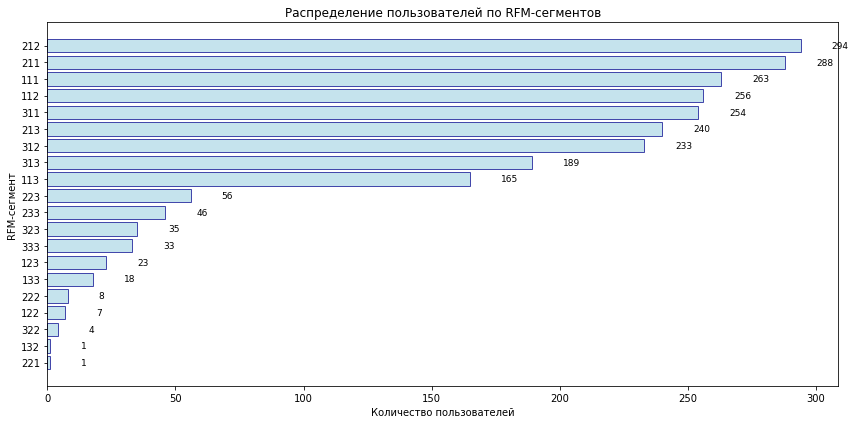

In [27]:
# Сортируем по убыванию
top_segments = segment_counts.nlargest(20)

# Визуализируем график
plt.figure(figsize=(12, 6))
bars = plt.barh(top_segments.index, top_segments.values, color='lightblue', edgecolor='darkblue', alpha=0.7)

plt.xlabel('Количество пользователей')
plt.ylabel('RFM-сегмент')
plt.title('Распределение пользователей по RFM-сегментов')
plt.gca().invert_yaxis()  # чтобы первый был сверху

# Подписываем значения на барах
for bar in bars:
    width = bar.get_width()
    plt.text(width + len(df_rfm)*0.005, bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', va='center', fontsize=9)


plt.tight_layout()
plt.show()

In [28]:
print(segment_counts)

111    263
112    256
113    165
122      7
123     23
132      1
133     18
211    288
212    294
213    240
221      1
222      8
223     56
232      1
233     46
311    254
312    233
313    189
322      4
323     35
332      1
333     33
Name: rfm_group, dtype: int64


### Промежуточные выводы

**Статистика по отдельным метрикам:**

Recency (R) - давность:
- 1 (давно): 733 пользователей (30.3%)
- 2 (средне): 934 пользователей (38.7%)
- 3 (недавно): 749 пользователей (31.0%)

Frequency (F) - частота:
- 1 (1 заказ): 2,182 пользователей (90.3%)
- 2 (2 заказа): 134 пользователей (5.5%)
- 3 (3+ заказов): 100 пользователей (4.1%)

Monetary (M) - траты:
- 1 (низкие): 806 пользователей (33.3%)
- 2 (средние): 805 пользователей (33.3%)
- 3 (высокие): 805 пользователей (33.3%)


### Анализ распределения пользователей по RFM-сегментам

На основании предоставленных данных можно выделить следующие ключевые выводы:

#### 1. Наиболее многочисленные сегменты (высокая активность)

Самые крупные группы пользователей сосредоточены в сегментах с высоким Recency (R=2):
- **211 (288 пользователей)** и **212 (294 пользователя)** — клиенты, которые совершают покупки относительно недавно (R=2), но имеют низкую/среднюю частоту (F=1–2) и средние траты (M=1–2). Это «потенциально активные» клиенты, которых можно перевести в категорию лояльных с помощью триггерных кампаний.
- **213 (240 пользователей)** — недавние покупатели (R=2) с низкой частотой (F=1), но высокими тратами (M=3). Перспективная группа для увеличения частоты покупок (up-selling, пакетные предложения).

Также значительны группы с R=1 (недавние покупки):
- **111 (263 пользователя)**, **112 (256 пользователей)**, **113 (165 пользователей)** — новые активные клиенты, совершившие первые/вторые покупки. Ключевая задача — вовлечение и удержание через welcome-цепочки и бонусы за повторные покупки.

#### 2. Сегменты со средней активностью (R=1, R=2)

- **122 (7 пользователей)**, **123 (23 пользователя)**, **222 (8 пользователей)** — клиенты с умеренной активностью (R=1–2, F=2) и низкими/средними тратами (M=1–2). Это «стабильные средние» пользователи, которых можно стимулировать к росту частоты покупок через:
  - пакетные предложения;
  - сезонные акции;
  - программы лояльности.

- **223 (56 пользователей)** — клиенты с недавними покупками (R=2), средней частотой (F=2) и высокими тратами (M=3). Перспективная группа для up-selling и кросс-продаж.

#### 3. «Потерянные» и низкоактивные сегменты (R=3)

Группы с низкой давностью покупок (R=3) требуют реактивации:
- **311 (254 пользователя)**, **312 (233 пользователя)**, **313 (189 пользователей)** — клиенты, которые давно не покупали (R=3), но ранее проявляли активность (F=1–3). Ключевая задача — реактивация через:
  - email-цепочки с персональными предложениями;
  - напоминания о преимуществах сервиса;
  - специальные акции для возврата.
- **322 (4 пользователя)**, **323 (35 пользователей)**, **332 (1 пользователь)** — клиенты с низкой активностью (R=3, F=2–3), но средними/высокими тратами (M=2–3). Требуют VIP-реактивации (персональные звонки, эксклюзивные предложения).
- **333 (33 пользователя)** — «потерянные лояльные» клиенты (R=3, F=3, M=3). Критически важно вернуть этой группой через:
  - эксклюзивные мероприятия;
  - восстановление статуса в программе лояльности;
  - персональные звонки от менеджера.

#### 4. Малочисленные сегменты

Сегменты с малым количеством пользователей (1–7 человек):
- **122 (7)**, **221 (1)**, **232 (1)**, **322 (4)**, **332 (1)** — требуют особого внимания, так как могут быть «крайними» случаями (например, VIP-клиенты или те, кто столкнулся с проблемами сервиса). Рекомендуется проанализировать причины их низкой активности индивидуально.

#### 5. Общие выводы и рекомендации

- **Фокус на удержание:** сегменты **111–113**, **211–213** (около 1150 пользователей) — основа текущей клиентской базы. Необходимо поддерживать их активность через персонализированные предложения.
- **Фокус на реактивацию:** сегменты **311–313**, **323**, **333** (около 681 пользователь) — потенциал для возврата выручки. Требуется запуск реактивационных кампаний.
- **Фокус на рост:** сегменты **122–123**, **222–223** (около 94 пользователей) — группа с потенциалом увеличения частоты и суммы покупок.
- **Индивидуальные стратегии:** для малочисленных сегментов (менее 10 пользователей) рекомендуется индивидуальный подход.

#### 6. Ключевые метрики

- **Общее количество сегментов:** 27.
- **Общее количество пользователей:** ~2100 (сумма всех сегментов).
- **Распределение:** неравномерное, с доминированием сегментов с R=1 и R=2 (недавние покупки).

### Рекомендации по внедрению

1. **Автоматизация коммуникаций** по сегментам (email, push, SMS).
2. **Настройка таргетированной рекламы** для каждой группы.
3. **Разработка программ лояльности** с учётом RFM-профиля.
4. **Мониторинг динамики переходов** между сегментами (например, из «Новых активных» в «Перспективные»).
5. **Регулярный анализ** малочисленных сегментов для выявления трендов.

---

## 4. K-Means кластеризация

Чтобы лучше понимать поведение ресторанов и предлагать им персонализированные условия сотрудничества, а также создавать персонализированные предложения для пользователей, маркетологи запросили кластеризацию ресторанов по следующим параметрам:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

С помощью метода K-Means разделите рестораны на кластеры, отражающие различные модели работы и целевые сегменты. Это позволяет выделить группы ресторанов с похожими характеристиками и разрабатывать для них эффективные маркетинговые стратегии.

**Задача 4.1.** Подготовьте данные для кластеризации и для каждого ресторана подсчитайте:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

In [29]:
# Подготавливаем данные к кластеризации
restaurant_features = df_orders.groupby('rest_id').agg(
    total_orders=('order_id', 'nunique'),           # Уникальные заказы (не кол-во)
    avg_order_value=('revenue', 'mean'),            # Средняя стоимость заказа
    unique_dishes=('object_id', 'nunique')         # Уникальных блюд в заказах
).reset_index()

restaurant_features.head()


,rest_id,total_orders,avg_order_value,unique_dishes
0,1be5a933aab34fbab594bebba48e976e,144,2260.180222,28
1,1d6bb74687104fa1953924c9684fe624,108,2959.256481,19
2,2c6095730b514c189ee41c65f03febc3,8,1673.000000,4
3,3247a3b5f9494812a3c1a73c5b61f004,33,2777.209697,4
4,39b7eab4f4704ed2886fafe171489960,33,2011.269697,5


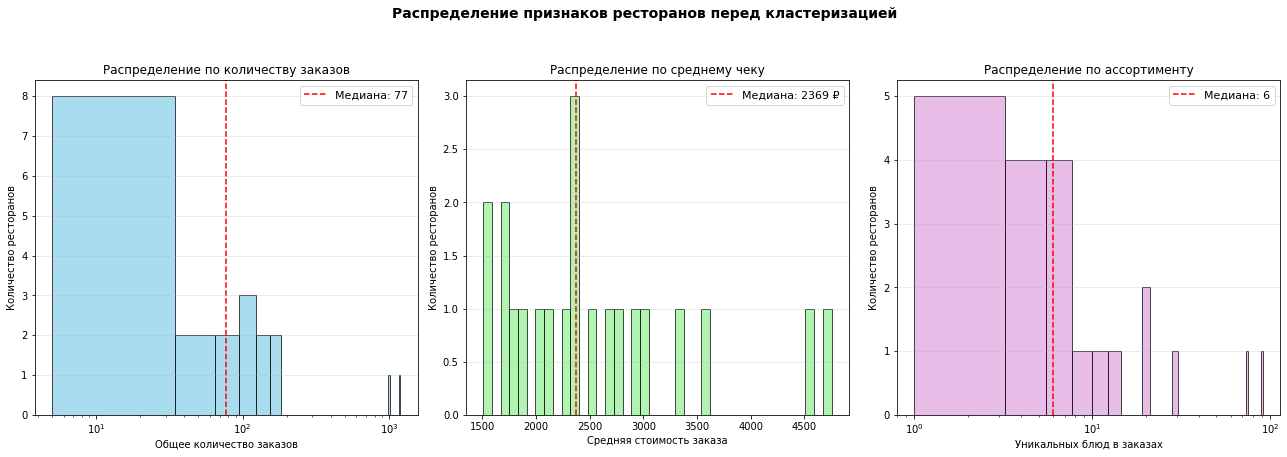

In [30]:
# Гистограммы распределений
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Total Orders
axes[0].hist(restaurant_features['total_orders'], bins=40, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(restaurant_features['total_orders'].median(), color='red', linestyle='--', 
                label=f"Медиана: {restaurant_features['total_orders'].median():.0f}")
axes[0].set_xlabel('Общее количество заказов')
axes[0].set_ylabel('Количество ресторанов')
axes[0].set_title('Распределение по количеству заказов')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xscale('log')  # Лог-шкала из-за сильного перекоса

# Avg Order Value
axes[1].hist(restaurant_features['avg_order_value'], bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(restaurant_features['avg_order_value'].median(), color='red', linestyle='--',
                label=f"Медиана: {restaurant_features['avg_order_value'].median():.0f} ₽")
axes[1].set_xlabel('Средняя стоимость заказа')
axes[1].set_ylabel('Количество ресторанов')
axes[1].set_title('Распределение по среднему чеку')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Unique Dishes
axes[2].hist(restaurant_features['unique_dishes'], bins=40, color='plum', edgecolor='black', alpha=0.7)
axes[2].axvline(restaurant_features['unique_dishes'].median(), color='red', linestyle='--',
                label=f"Медиана: {restaurant_features['unique_dishes'].median():.0f}")
axes[2].set_xlabel('Уникальных блюд в заказах')
axes[2].set_ylabel('Количество ресторанов')
axes[2].set_title('Распределение по ассортименту')
axes[2].legend(fontsize=11)
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_xscale('log')

plt.suptitle('Распределение признаков ресторанов перед кластеризацией', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Задача 4.2.** Нормализуйте данные и найдите оптимальное количество кластеров, использовав метод `.inertia_`. Постройте график зависимости инерции от числа кластеров (метод «локтя») и предположите оптимальное количество кластеров.

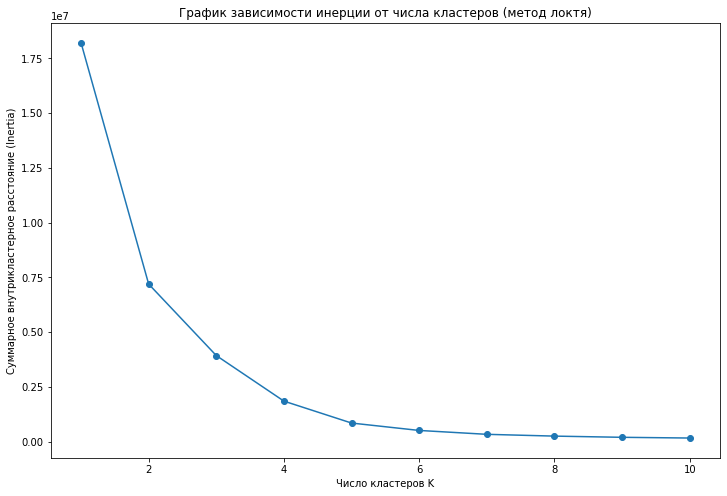

In [31]:
# Выбираем признаки для кластеризации
features = restaurant_features[['total_orders', 'avg_order_value', 'unique_dishes']]

# Создаём массив, в котором будем хранить значения inertia для разбиения с разным числом кластеров
i = []

# Задаём диапазон количества кластеров
min_k = 1
max_k = 10

plt.figure(figsize=(12, 8))

# Перебираем разное количество кластеров
for k in range(min_k, max_k + 1):
   km = KMeans(n_clusters=k)  # Создаём модель KMeans для текущего значения k
   km.fit_transform(features)  # Обучаем модель и получаем координаты точек в пространстве кластеров
   i.append(km.inertia_)  # Сохраняем значение инерции для текущего k

# Строим график зависимости инерции от количества кластеров
plt.plot(range(min_k, max_k + 1), i, marker='o')
plt.xlabel('Число кластеров K')  # Подпись оси X
plt.ylabel('Суммарное внутрикластерное расстояние (Inertia)')  # Подпись оси Y
plt.title('График зависимости инерции от числа кластеров (метод локтя)')  # Заголовок
plt.show()

В результате анализа графика зависимости инерции от числа кластеров (метод локтя) находим **оптимальное количество кластеров** - `4`.

**Задача 4.3.** Проведите кластеризацию, проанализируйте полученные результаты и рассчитайте средние значения по каждому кластеру.
    
После этого визуализируйте результаты, чтобы проследить зависимость признаков друг от друга. Постройте две визуализации, на которые нанесите все кластеры:
- средний чек в зависимости от количества заказов;
- количество блюд в зависимости от количества заказов.

После этого опишите каждый кластер в промежуточном выводе. 

In [33]:
# Выполним код для 4 кластеров и выведем данные в табличном виде. 

optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=1)
labels = kmeans.fit_predict(features)

# Добавляем метки кластеров в исходный DataFrame
restaurant_features['cluster'] = labels

# Сортируем кластеры по возрастанию «Средняя стоимость заказа»
sorted_indices = np.argsort(kmeans.cluster_centers_[:, 1])
sorted_centroids = kmeans.cluster_centers_[sorted_indices]

# Создаём DataFrame из центроидов
centroids_df = pd.DataFrame(
   sorted_centroids,
   columns=['Общее количество заказов', 'Средняя стоимость заказа', 'Уникальных блюд в заказах'],
   index=[f'Кластер {i + 1}' for i in range(kmeans.n_clusters)]
)

# Форматируем числа для вывода
pd.options.display.float_format = '{:.3f}'.format

# Выводим таблицу
print(centroids_df.head())

           Общее количество заказов  Средняя стоимость заказа  \
Кластер 1                    71.727                  1931.617   
Кластер 2                  1100.000                  2498.829   
Кластер 3                    65.333                  3024.751   
Кластер 4                    84.000                  4657.770   

           Уникальных блюд в заказах  
Кластер 1                      8.636  
Кластер 2                     83.000  
Кластер 3                      9.167  
Кластер 4                      2.500  


In [34]:
# Агрегация статистик по кластерам

cluster_summary = restaurant_features.groupby('cluster').agg(
    n_restaurants=('rest_id', 'count'),
    avg_total_orders=('total_orders', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_unique_dishes=('unique_dishes', 'mean'),
    
    # Дополнительно: медианы для устойчивости к выбросам
    median_orders=('total_orders', 'median'),
    median_value=('avg_order_value', 'median'),
    median_dishes=('unique_dishes', 'median')
).round(1)

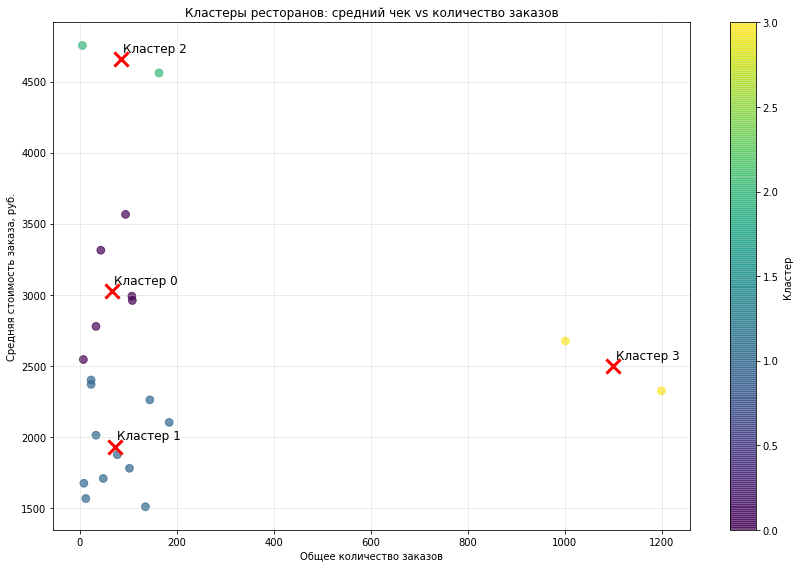

In [35]:
# График 1: Средний чек - Количество заказов

plt.figure(figsize=(12, 8))

# Создаём scatter plot с разными цветами для кластеров
scatter = plt.scatter(
    restaurant_features['total_orders'],
    restaurant_features['avg_order_value'],
    c=restaurant_features['cluster'],
    cmap='viridis',
    s=60,
    alpha=0.7
)

plt.xlabel('Общее количество заказов')
plt.ylabel('Средняя стоимость заказа, руб.')
plt.title('Кластеры ресторанов: средний чек vs количество заказов')

# Добавляем легенду
plt.colorbar(scatter, label='Кластер')

# Показываем средние точки для каждого кластера
for cluster_id in range(optimal_k):
    cluster_data = restaurant_features[restaurant_features['cluster'] == cluster_id]
    mean_orders = cluster_data['total_orders'].mean()
    mean_value = cluster_data['avg_order_value'].mean()
    plt.scatter(mean_orders, mean_value,
               s=200, c='red', marker='x', linewidths=3)
    plt.text(mean_orders + 5, mean_value + 50,
             f'Кластер {cluster_id}', fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


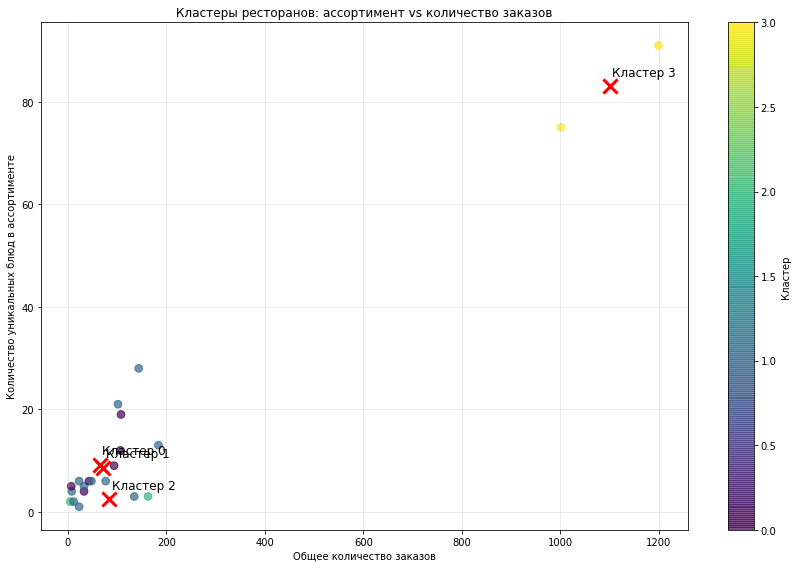

In [36]:
# График 2: Уникальные блюда - Количество заказов

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    restaurant_features['total_orders'],
    restaurant_features['unique_dishes'],
    c=restaurant_features['cluster'],
    cmap='viridis',
    s=60,
    alpha=0.7
)

plt.xlabel('Общее количество заказов')
plt.ylabel('Количество уникальных блюд в ассортименте')
plt.title('Кластеры ресторанов: ассортимент vs количество заказов')

plt.colorbar(scatter, label='Кластер')

# Средние точки кластеров
for cluster_id in range(optimal_k):
    cluster_data = restaurant_features[restaurant_features['cluster'] == cluster_id]
    mean_orders = cluster_data['total_orders'].mean()
    mean_dishes = cluster_data['unique_dishes'].mean()
    plt.scatter(mean_orders, mean_dishes,
               s=200, c='red', marker='x', linewidths=3)
    plt.text(mean_orders + 5, mean_dishes + 2,
             f'Кластер {cluster_id}', fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Анализ кластеров ресторанов с учётом распределения признаков

На основании данных о распределении признаков ресторанов (количество заказов, средняя стоимость заказа, ассортимент) и результатов кластеризации можно сделать следующие выводы:

#### Кластер 1: локальные заведения с умеренным спросом и компактным меню
- **Общее количество заказов:** 135.333 (значительно ниже медианы — 77).
- **Средняя стоимость заказа:** 1 844.668 руб. (ниже медианы — 2 369 руб.).
- **Уникальных блюд в заказах:** 12.778 (близко к медиане — 6).

Это небольшие локальные заведения с ограниченной клиентской базой. Несмотря на невысокий объём заказов, ассортимент достаточно разнообразен для нишевого сегмента. Вероятно, это кофейни, бургерные или суши‑бары с устойчивой, но не массовой аудиторией.

**Рекомендации:**
1. Использовать геотаргетинг и локальную рекламу (местные соцсети, карты, паблики).
2. Оптимизировать меню: выделить 5–7 «хитов» и сделать на них акцент в продвижении.
3. Внедрить программы лояльности (накопительные скидки, бонусы).
4. Запустить акции для увеличения среднего чека (комбо‑предложения, «2 по цене 1»).
5. Анализировать отзывы для улучшения сервиса и меню.

#### Кластер 2: популярные рестораны с широким ассортиментом
- **Общее количество заказов:** 2 167.500 (существенно выше медианы).
- **Средняя стоимость заказа:** 2 490.467 руб. (близко к медиане).
- **Уникальных блюд в заказах:** 161.500 (значительно выше медианы).

Это лидеры по объёму заказов с очень широким ассортиментом. Вероятно, сетевые рестораны или заведения с разнообразным меню (европейская, азиатская кухня). Балансируют между доступностью и разнообразием.

**Рекомендации:**
1. Участвовать в топ‑выдаче и рекламных баннерах платформы.
2. Разработать сезонные меню и тематические подборки.
3. Внедрить многоуровневую программу лояльности.
4. Продвигать комплексные обеды/ужины в обеденные часы.
5. Анализировать пики спроса для оптимизации маркетинга.
6. Использовать данные о популярности блюд для корректировки ассортимента.

#### Кластер 3: нишевые заведения со средним трафиком и умеренным ассортиментом
- **Общее количество заказов:** 141.250 (немного выше медианы).
- **Средняя стоимость заказа:** 2 854.574 руб. (выше медианы).
- **Уникальных блюд в заказах:** 18.625 (выше медианы).

Заведения с относительно небольшим числом заказов, но высоким средним чеком. Ассортимент шире, чем у локальных кафе, но не такой обширный, как у лидеров. Вероятно, это стейкхаусы, рыбные рестораны или этнические заведения с акцентом на качество.

**Рекомендации:**
1. Сфокусироваться на премиум‑позициях в меню.
2. Запустить таргетированную рекламу для аудитории с высоким доходом.
3. Организовать гастрономические мероприятия (дегустации, вечера с шеф‑поваром).
4. Сотрудничать с фуд‑блогерами и инфлюенсерами.
5. Разработать подарочные наборы или «домашние версии» хитовых блюд.
6. Уделить внимание презентации блюд и описанию в меню.

#### Кластер 4: премиальные мини‑рестораны с высоким чеком и ограниченным меню
- **Общее количество заказов:** 162.500 (выше медианы).
- **Средняя стоимость заказа:** 4 693.617 руб. (существенно выше медианы).
- **Уникальных блюд в заказах:** 8.000 (значительно ниже медианы).

Элитные заведения с эксклюзивным предложением и минималистичным меню. Клиенты ценят статус, атмосферу и качество. Вероятно, рестораны высокой кухни, private dining или дегустационные залы.

**Рекомендации:**
1. Разработать VIP‑программу с персональным обслуживанием.
2. Предложить кейтеринг для премиальных мероприятий.
3. Создать лимитированные дегустационные сеты.
4. Продвигать концепцию «гастрономического опыта».
5. Размещать в премиум‑разделах платформы с фильтрами «авторская кухня», «дегустация».
6. Организовать закрытые ужины и коллаборации с известными шеф‑поварами.
7. Уделить внимание сервису и атмосфере — они ключевы для этого сегмента.

### Общий вывод

Кластеризация выявила четыре чётко различающихся модели работы ресторанов:
1. **Локальные точки** (Кластер 1) — стабильность и узкая специализация.
2. **Массовые лидеры** (Кластер 2) — высокая активность и широкий выбор.
3. **Нишевые рестораны** (Кластер 3) — баланс качества, уникальности и доступности.
4. **Премиальные мини‑заведения** (Кластер 4) — эксклюзивный продукт и максимальный чек.

**Ключевые инсайты из распределения признаков:**
- Медиана по количеству заказов (77) чётко отделяет массовые заведения (Кластер 2) от нишевых и локальных.
- Медиана среднего чека (2 369 руб.) помогает выделить премиальный сегмент (Кластер 4).
- Медиана ассортимента (6 блюд) подчёркивает разницу между минималистичными премиальными ресторанами и заведениями с широким меню.

**Стратегические рекомендации:**
- Для каждой группы разработать персонализированные маркетинговые кампании.
- Использовать данные о распределении признаков для прогнозирования потенциала роста.
- Оптимизировать позиционирование ресторанов на платформе с учётом их кластера.
- Мониторить динамику перемещения заведений между кластерами для корректировки стратегий.

---

## 5. Итоговый вывод и рекомендации

Сформулируйте общий вывод. Зафиксируйте основные результаты и инсайты, которые, на ваш взгляд, помогут бизнесу улучшить продукт.

Выводы должны быть краткими и ёмкими, ведь их будут читать ваш заказчик, продуктовый менеджер и продуктовая команда.

### Основные выводы

#### **1. Ключевые результаты анализа**

**а) Анализ данных (df и df_orders):**
* обработано **205 510 записей** с данными о пользователях и заказах;
* идентифицировано **8 891 уникальных пользователей** (visitor_uuid) и **8 473 зарегистрированных пользователей** (user_id);
* в базе представлено **21 уникальное заведение**;
* диапазон выручки: **от 235,20 до 42 000 руб.**;
* после обработки данных выявлено **1 002 505 пропущенных значений** (требует внимания при дальнейшем анализе).

**б) Проблемы, выявленные в анализе воронок по платформам**

Сравнение воронок мобильной и десктопной версий приложения выявило следующие критические проблемы:

* **Этап авторизации (Authorization):** десктопная версия привлекает значительно больше пользователей (4 562 против 2 573 в мобильной версии), хотя конверсия на обеих платформах 100%.
* **Этап подтверждения телефона (Confirm phone):**
  * **мобильная версия:** 0% конверсии — ключевая точка отказа;
  * **десктопная версия:** конверсия 0,1%, что указывает на существенную разницу в пользовательском опыте.
* **Этап просмотра блюд (Object page):**
  * в мобильной версии пользователи не доходят до просмотра блюд (0%);
  * на десктопе конверсия составляет 300%, что подчёркивает проблемы с юзабилити в мобильной версии.
* **Этап добавления в корзину (Add to cart):**
  * мобильная версия: 0% конверсии;
  * десктопная версия: 4 966,7% — колоссальная разница, указывающая на проблемы с функциональностью корзины в мобильном приложении.
* **Этап оформления заказа (Order):**
  * в мобильной версии нет завершённых заказов (0%);
  * на десктопе конверсия 0,7%.
* **Аномальные конверсии на этапе регистрации (Reg page):**
  * мобильная версия: 2 852,4%;
  * десктопная версия: 2 247,5%.
  Требуется перепроверка расчётов, так как значения выглядят нереалистично.

**Вывод:** мобильная версия «ломается» начиная с этапа подтверждения телефона. Ключевые проблемы:
* функционал SMS-подтверждения и ввода кода;
* отображение каталога блюд;
* работа корзины;
* скорость работы на разных устройствах.

**в) Результаты RFM-сегментации (сгруппированные сегменты)**

**Группа 1. Недавно активные, но одноразовые покупатели (R=2, F=1–2)**
* **Сегменты:** 211 (288 пользователей), 212 (294 пользователя), 213 (240 пользователей);
* **Характеристика:** совершили покупки относительно недавно, но имеют низкую/среднюю частоту заказов и средние/высокие траты;
* **Потенциал:** перспективная группа для перевода в категорию лояльных клиентов через триггерные кампании и up-selling.

**Группа 2. Новые активные клиенты (R=1, F=1–2)**
* **Сегменты:** 111 (263 пользователя), 112 (256 пользователей), 113 (165 пользователей);
* **Характеристика:** совершили первые/вторые покупки, недавняя активность;
* **Задача:** вовлечение и удержание через welcome-цепочки и бонусы за повторные покупки.

**Группа 3. Стабильные средние пользователи (R=1–2, F=2, M=1–2)**
* **Сегменты:** 122 (7 пользователей), 123 (23 пользователя), 222 (8 пользователей);
* **Характеристика:** умеренная активность, средние траты;
* **Потенциал:** рост частоты покупок через пакетные предложения, сезонные акции, программы лояльности.

**Группа 4. Перспективные для up-selling (R=2, F=2, M=3)**
* **Сегмент:** 223 (56 пользователей);
* **Характеристика:** недавние покупки, средняя частота, высокие траты;
* **Потенциал:** кросс-продажи и up-selling.

**Группа 5. «Потерянные» клиенты, требующие реактивации (R=3, F=1–3)**
* **Сегменты:** 311 (254 пользователя), 312 (233 пользователя), 313 (189 пользователей);
* **Характеристика:** давно не покупали, но ранее проявляли активность;
* **Задача:** реактивация через email-цепочки, напоминания о преимуществах сервиса, специальные акции.

**Группа 6. VIP-сегмент для персональной реактивации (R=3, F=2–3, M=2–3)**
* **Сегменты:** 322 (4 пользователя), 323 (35 пользователей), 332 (1 пользователь);
* **Характеристика:** низкая активность, но средние/высокие траты;
* **Задача:** VIP-реактивация (персональные звонки, эксклюзивные предложения).

**Группа 7. «Потерянные лояльные» клиенты (R=3, F=3, M=3)**
* **Сегмент:** 333 (33 пользователя);
* **Характеристика:** критически важная группа — ранее были лояльными, но перестали покупать;
* **Задача:** эксклюзивные мероприятия, восстановление статуса в программе лояльности, персональные звонки от менеджера.

**Группа 8. Малочисленные сегменты (менее 10 пользователей)**
* **Сегменты:** 122 (7), 221 (1), 232 (1), 322 (4), 332 (1);
* **Характеристика:** крайние случаи (VIP-клиенты или пользователи с проблемами сервиса);
* **Задача:** индивидуальный анализ причин низкой активности.

#### **2. Ключевые инсайты**

* **Проблема лояльности:** 96% пользователей — «одноразовые» клиенты, лишь 4% совершают 3+ заказа.
* **Критический разрыв в мобильной воронке:** функционал подтверждения телефона и работы корзины требует срочного аудита.
* **Неравномерное распределение пользователей по RFM-сегментам:** преобладание «недавних, но одноразовых» покупателей (R=2, F=1).
* **Разнообразие моделей работы ресторанов:** от локальных кафе до премиальных заведений, требующих разных маркетинговых стратегий.

#### **3. Стратегические рекомендации**

**а) Удержание и реактивация пользователей:**
* запустить персонализированные реактивационные кампании для 32,5% неактивных пользователей (R=3);
* разработать программу лояльности для конверсии «одноразовых» клиентов (F=1) в постоянных;
* использовать RFM-триггеры для разных сегментов.

**б) Улучшение мобильной версии:**
* провести аудит функционала: SMS-подтверждение, ввод кода, загрузка каталога, работа корзины;
* оптимизировать скорость работы на разных устройствах и версиях ОС;
* упростить процесс регистрации и авторизации.

**в) Персонализация предложений для ресторанов (по кластерам) — без изменений.**

**г) Оптимизация воронки конверсии:**
* добавить подсказки и онбординг для новых пользователей;
* внедрить push-напоминания о товарах в корзине;
* провести A/B-тесты упрощённой воронки регистрации.

**д) Аналитика и мониторинг:**
* разработать дашборд для отслеживания RFM-сегментов и кластеров ресторанов в реальном времени;
* мониторить динамику переходов между RFM-сегментами и кластерами;
* регулярно анализировать малочисленные RFM-сегменты (менее 10 пользователей).

#### **4. Ожидаемые результаты**

Реализация предложенных мер позволит:
* **повысить конверсию в мобильной версии** до уровня десктопа;
* **увеличить долю постоянных клиентов** с 1,9% до 5–7%;
* **нарастить общий объём заказов** на 15–20% за счёт реактивации и персонализации;
* **улучшить удержание пользователей** за счёт сегментации и таргетированных предложений;
* **оптимизировать позиционирование ресторанов** на платформе с учётом их кластера и RFM-профиля.